# VR Spatial Information & Stability — Cross-Reference with Cell Type

## Purpose

Before using cell-type labels (GC, NG) to select cells for the VR NGS catalogue, this notebook
asks: **how well do VR spatial information and spatial stability separate GC and NG cells, and
where should thresholds sit?**

Both metrics use shuffle-based significance (`sig` column in each parquet):

- **Spatial information** (bits/spike): how much the firing rate of a cell deviates from a
  uniform distribution over track position. High SI → position-selective firing.
- **Spatial stability**: Pearson r between the first- and second-half session rate maps
  (`travel = 0` row). High stability → reproducible place field across the session.

This notebook:

1. Loads all VR `spatial_information.parquet` and `spatial_stability.parquet` files
2. Merges with `cell_classifications.csv` for `cell_type`, `brain_region`, `firing_rate_VR`
3. Filters to **MEC principal cells** (`brain_region` starts `ENTm`, `firing_rate_VR < 10 Hz`)
4. Shows distributions of SI and stability across **GC** and **NG** cell types
5. Shows a joint SI × stability scatter to identify doubly-spatial cells
6. Sweeps absolute thresholds to help decide which NG cells qualify as spatial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu
from pathlib import Path
import ast, warnings
warnings.filterwarnings('ignore')

In [2]:
source_path         = '/Users/harryclark/Downloads/COHORT12/'
CLASSIFICATIONS_CSV = '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv'

mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    22: [33,34,35,36,37,38,39,40,41],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

TYPE_COLOURS = {'GC': '#E53935', 'NG': '#1565C0', 'Other': '#78909C'}
TYPE_ORDER   = ['GC', 'NG', 'Other']

In [3]:
# ── Load spatial_information.parquet ─────────────────────────────────────────
si_rows = []
for mouse, days in mouse_days.items():
    for day in days:
        p = (Path(source_path) / f'M{mouse}' / f'D{day:02}' /
             'VR' / 'tuning_scores' / 'spatial_information.parquet')
        if not p.exists():
            continue
        df_p = pd.read_parquet(p, columns=['cluster_id','brain_region',
                                            'spatial_information','sig',
                                            'null_spatial_information'])
        df_p['mouse'] = int(mouse)
        df_p['day']   = int(day)
        si_rows.append(df_p)

df_si = pd.concat(si_rows, ignore_index=True)
print(f'SI:  {len(df_si)} records from {len(si_rows)} sessions')

# Parse null SI → 95th percentile (stored as Python list literal)
def null_p95_list(null_val):
    try:
        arr = np.asarray(ast.literal_eval(null_val), dtype=float)
        return float(np.nanpercentile(arr, 95))
    except Exception:
        return np.nan

df_si['si_null_p95'] = df_si['null_spatial_information'].apply(null_p95_list)
df_si = df_si.rename(columns={'sig': 'si_sig'})

# ── Load spatial_stability.parquet (travel=0 only) ────────────────────────────
st_rows = []
for mouse, days in mouse_days.items():
    for day in days:
        p = (Path(source_path) / f'M{mouse}' / f'D{day:02}' /
             'VR' / 'tuning_scores' / 'spatial_stability.parquet')
        if not p.exists():
            continue
        df_p = pd.read_parquet(p, columns=['cluster_id','travel','stability','sig'])
        df_p = df_p[df_p['travel'] == 0][['cluster_id','stability','sig']].copy()
        df_p['mouse'] = int(mouse)
        df_p['day']   = int(day)
        st_rows.append(df_p)

df_st = pd.concat(st_rows, ignore_index=True)
df_st = df_st.rename(columns={'sig': 'st_sig'})
print(f'Stab: {len(df_st)} records from {len(st_rows)} sessions')

# ── Merge SI + stability + cell_classifications ───────────────────────────────
df_class = pd.read_csv(CLASSIFICATIONS_CSV)[
    ['mouse','day','cluster_id','cell_type','firing_rate_VR','SC_x']
].copy()
df_class['mouse'] = df_class['mouse'].astype(int)
df_class['day']   = df_class['day'].astype(int)
df_class['ml']    = df_class['SC_x'].abs()

df = (df_si[['mouse','day','cluster_id','brain_region',
              'spatial_information','si_sig','si_null_p95']]
      .merge(df_st[['mouse','day','cluster_id','stability','st_sig']],
             on=['mouse','day','cluster_id'], how='outer')
      .merge(df_class, on=['mouse','day','cluster_id'], how='inner'))

# ── MEC + principal cells ─────────────────────────────────────────────────────
df = df[
    df['brain_region'].str.startswith('ENTm', na=False) &
    (df['firing_rate_VR'] < 10)
].copy()

# ── Parse ENTm layer (e.g. 'ENTm2' → 2) ─────────────────────────────────────
df['layer'] = pd.to_numeric(
    df['brain_region'].str.extract(r'ENTm(\d+)')[0], errors='coerce')
df['depth'] = df['layer'].apply(
    lambda x: 'superficial' if x in [1.0, 2.0, 3.0] else
              ('deep'        if x in [5.0, 6.0]       else 'unknown'))
df['both_sig'] = df['si_sig'] & df['st_sig']

print(f'\nMEC principal cells (ENTm*, FR<10Hz): {len(df)}')
print(df['cell_type'].value_counts().to_string())
print(f'\nDepth breakdown:')
print(df['depth'].value_counts().to_string())
print(f'\n{df.groupby(["depth","cell_type"]).size().unstack(fill_value=0).to_string()}')
print(f'\n{"Cell type":8s}  {"SI sig":>10s}  {"Stab sig":>10s}  {"Both sig":>10s}')
print('-' * 48)
for ct in TYPE_ORDER:
    sub = df[df['cell_type'] == ct]
    n   = len(sub)
    print(f'{ct:8s}  '
          f'{sub["si_sig"].sum():4d}/{n} ({100*sub["si_sig"].mean():.0f}%)  '
          f'{sub["st_sig"].sum():4d}/{n} ({100*sub["st_sig"].mean():.0f}%)  '
          f'{(sub["si_sig"] & sub["st_sig"]).sum():4d}/{n} '
          f'({100*(sub["si_sig"] & sub["st_sig"]).mean():.0f}%)')

SI:  13001 records from 81 sessions
Stab: 13001 records from 81 sessions

MEC principal cells (ENTm*, FR<10Hz): 5367
cell_type
NG       3980
Other     894
GC        493

Depth breakdown:
depth
superficial    3543
deep           1824

cell_type     GC    NG  Other
depth                        
deep         112  1414    298
superficial  381  2566    596

Cell type      SI sig    Stab sig    Both sig
------------------------------------------------
GC         436/493 (88%)   356/493 (72%)   355/493 (72%)
NG        3733/3980 (94%)  3335/3980 (84%)  3313/3980 (83%)
Other      758/894 (85%)   663/894 (74%)   655/894 (73%)


---
## All MEC principal cells — no cell-type classification

Examine SI and stability for the full population, grouped only by cortical depth
(superficial layers 1–3 vs deep layers 5–6), before introducing GC / NG labels.

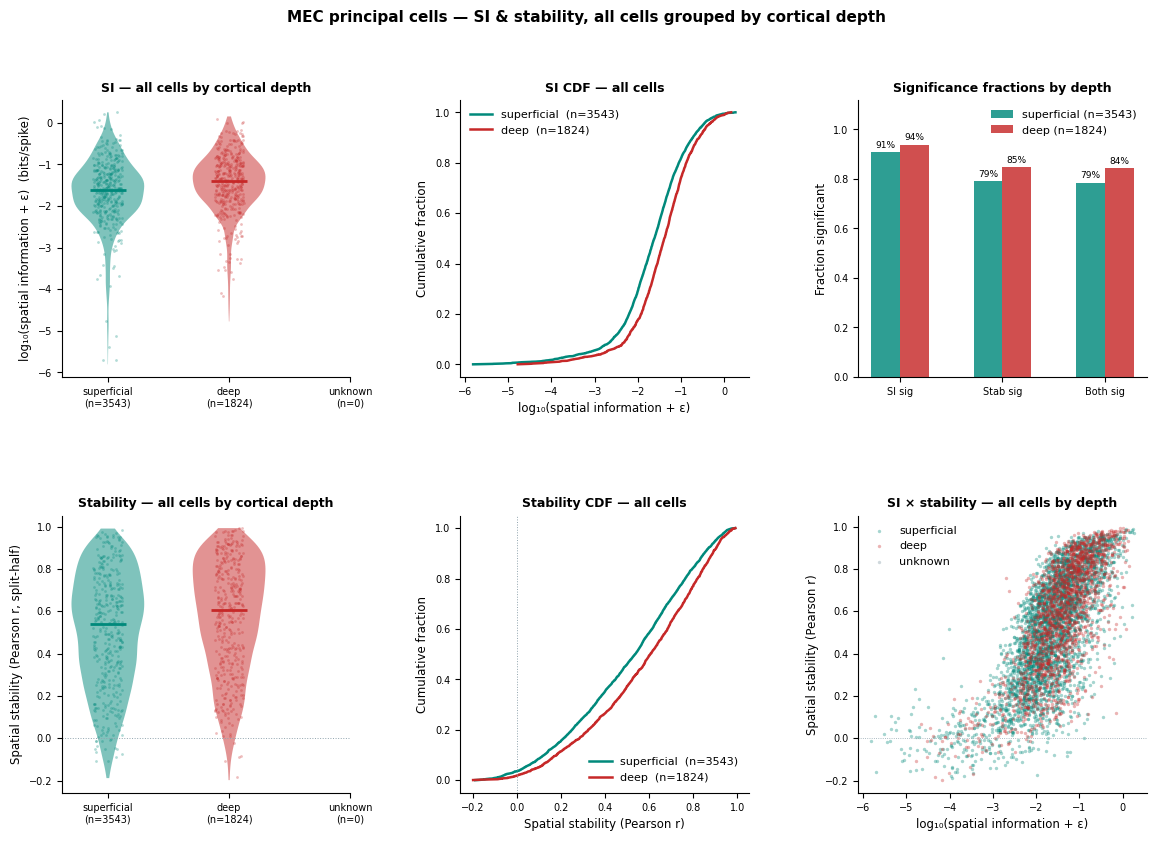

In [4]:
DEPTH_COLOURS = {'superficial': '#00897B', 'deep': '#C62828', 'unknown': '#78909C'}
DEPTH_ORDER   = ['superficial', 'deep', 'unknown']

fig, axes = plt.subplots(2, 3, figsize=(14, 9),
                         gridspec_kw=dict(hspace=0.50, wspace=0.38))

# ── A: violin — SI per depth ──────────────────────────────────────────────────
ax = axes[0, 0]
for xi, depth in enumerate(DEPTH_ORDER):
    sub = df[df['depth'] == depth]['spatial_information'].dropna()
    if len(sub) == 0: continue
    parts = ax.violinplot(np.log10(sub + 1e-6), positions=[xi], widths=0.6,
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(DEPTH_COLOURS[depth]); pc.set_alpha(0.5)
    parts['cmedians'].set_color(DEPTH_COLOURS[depth]); parts['cmedians'].set_linewidth(2.0)
    rng    = np.random.default_rng(xi)
    n_show = min(len(sub), 400)
    idx_s  = rng.choice(len(sub), n_show, replace=False)
    jitter = rng.uniform(-0.12, 0.12, n_show)
    ax.scatter(xi + jitter, np.log10(sub.iloc[idx_s] + 1e-6),
               s=4, color=DEPTH_COLOURS[depth], alpha=0.30, lw=0)
ax.set_xticks(range(len(DEPTH_ORDER)))
ax.set_xticklabels([f'{d}\n(n={len(df[df["depth"]==d])})' for d in DEPTH_ORDER], fontsize=8)
ax.set_ylabel('log₁₀(spatial information + ε)  (bits/spike)', fontsize=8.5)
ax.set_title('SI — all cells by cortical depth', fontsize=9, fontweight='bold')
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── B: SI CDF per depth ───────────────────────────────────────────────────────
ax = axes[0, 1]
for depth in DEPTH_ORDER:
    sub = np.sort(df[df['depth'] == depth]['spatial_information'].dropna().values)
    if len(sub) == 0: continue
    cdf = np.arange(1, len(sub)+1) / len(sub)
    ax.plot(np.log10(sub + 1e-6), cdf, color=DEPTH_COLOURS[depth],
            lw=1.8, label=f'{depth}  (n={len(sub)})')
ax.set_xlabel('log₁₀(spatial information + ε)', fontsize=8.5)
ax.set_ylabel('Cumulative fraction', fontsize=8.5)
ax.set_title('SI CDF — all cells', fontsize=9, fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── C: Fraction sig breakdown — superficial vs deep ──────────────────────────
ax = axes[0, 2]
crit_labels = ['SI sig', 'Stab sig', 'Both sig']
crit_cols_c = ['si_sig', 'st_sig', 'both_sig']
bar_colours = ['#F57C00', '#0288D1', '#2E7D32']
x      = np.arange(len(crit_labels))
width  = 0.28
for di, depth in enumerate(['superficial', 'deep']):
    sub   = df[df['depth'] == depth]
    fracs = [sub[c].mean() for c in crit_cols_c]
    bars  = ax.bar(x + (di - 0.5) * width, fracs, width,
                   color=DEPTH_COLOURS[depth], alpha=0.82, lw=0,
                   label=f'{depth} (n={len(sub)})')
    for b, frac in zip(bars, fracs):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{frac*100:.0f}%', ha='center', va='bottom', fontsize=6.5)
ax.set_xticks(x); ax.set_xticklabels(crit_labels, fontsize=8.5)
ax.set_ylabel('Fraction significant', fontsize=8.5)
ax.set_title('Significance fractions by depth', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=8, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── D: violin — stability per depth ──────────────────────────────────────────
ax = axes[1, 0]
for xi, depth in enumerate(DEPTH_ORDER):
    sub = df[df['depth'] == depth]['stability'].dropna()
    if len(sub) == 0: continue
    parts = ax.violinplot(sub, positions=[xi], widths=0.6,
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(DEPTH_COLOURS[depth]); pc.set_alpha(0.5)
    parts['cmedians'].set_color(DEPTH_COLOURS[depth]); parts['cmedians'].set_linewidth(2.0)
    rng    = np.random.default_rng(xi + 10)
    n_show = min(len(sub), 400)
    idx_s  = rng.choice(len(sub), n_show, replace=False)
    jitter = rng.uniform(-0.12, 0.12, n_show)
    ax.scatter(xi + jitter, sub.iloc[idx_s],
               s=4, color=DEPTH_COLOURS[depth], alpha=0.30, lw=0)
ax.axhline(0, color='#90A4AE', lw=0.7, ls=':')
ax.set_xticks(range(len(DEPTH_ORDER)))
ax.set_xticklabels([f'{d}\n(n={df[df["depth"]==d]["stability"].notna().sum()})' for d in DEPTH_ORDER], fontsize=8)
ax.set_ylabel('Spatial stability (Pearson r, split-half)', fontsize=8.5)
ax.set_title('Stability — all cells by cortical depth', fontsize=9, fontweight='bold')
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── E: Stability CDF per depth ────────────────────────────────────────────────
ax = axes[1, 1]
for depth in DEPTH_ORDER:
    sub = np.sort(df[df['depth'] == depth]['stability'].dropna().values)
    if len(sub) == 0: continue
    cdf = np.arange(1, len(sub)+1) / len(sub)
    ax.plot(sub, cdf, color=DEPTH_COLOURS[depth], lw=1.8,
            label=f'{depth}  (n={len(sub)})')
ax.axvline(0, color='#90A4AE', lw=0.7, ls=':')
ax.set_xlabel('Spatial stability (Pearson r)', fontsize=8.5)
ax.set_ylabel('Cumulative fraction', fontsize=8.5)
ax.set_title('Stability CDF — all cells', fontsize=9, fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── F: SI × stability scatter — all cells coloured by depth ──────────────────
ax = axes[1, 2]
for depth in DEPTH_ORDER:
    sub = df[df['depth'] == depth].dropna(subset=['spatial_information','stability'])
    ax.scatter(np.log10(sub['spatial_information'] + 1e-6), sub['stability'],
               s=6, color=DEPTH_COLOURS[depth], alpha=0.35, lw=0, label=depth)
ax.axhline(0, color='#90A4AE', lw=0.6, ls=':')
ax.set_xlabel('log₁₀(spatial information + ε)', fontsize=8.5)
ax.set_ylabel('Spatial stability (Pearson r)', fontsize=8.5)
ax.set_title('SI × stability — all cells by depth', fontsize=9, fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

fig.suptitle('MEC principal cells — SI & stability, all cells grouped by cortical depth',
             fontsize=11, fontweight='bold')
plt.savefig('vr_spatial_info_all_cells.pdf', bbox_inches='tight', dpi=150)
plt.show()

---
## Plots

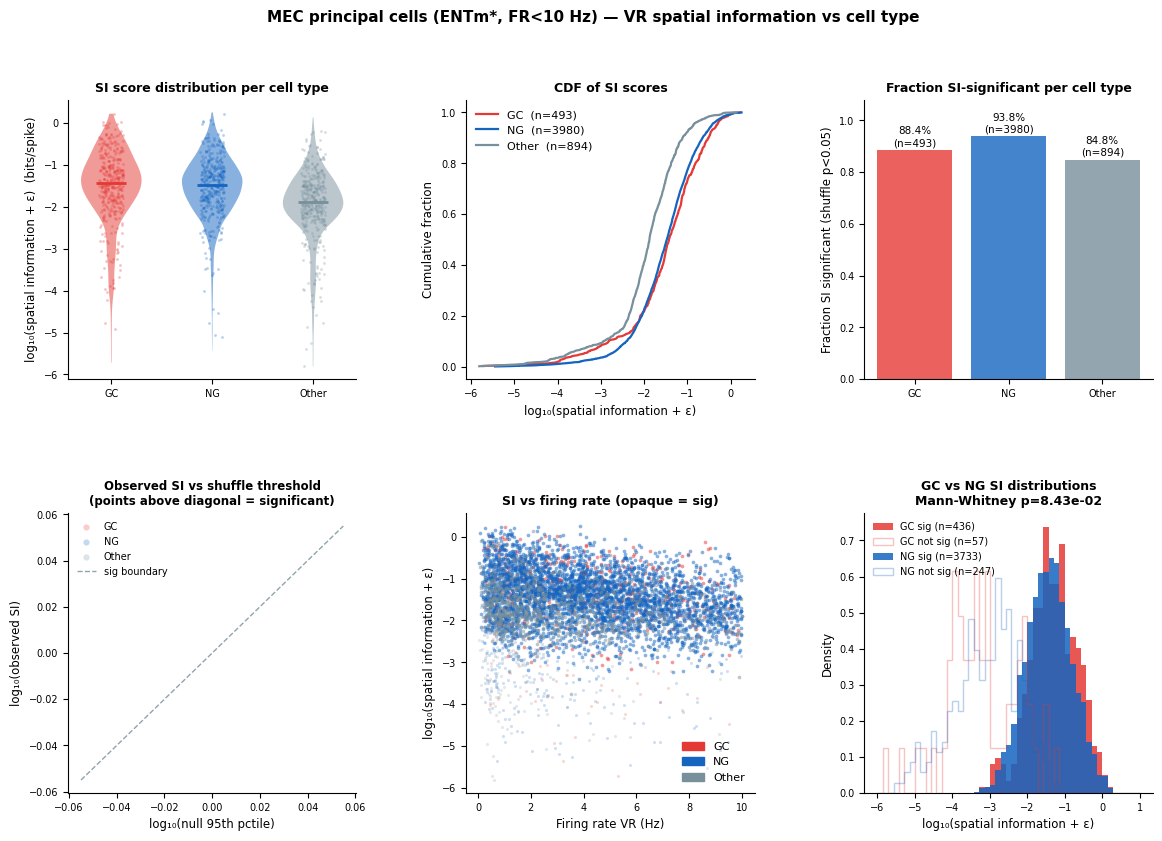

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9),
                         gridspec_kw=dict(hspace=0.48, wspace=0.38))

# ── A: violin — SI score per cell type ───────────────────────────────────────
ax = axes[0, 0]
parts_list = []
for xi, ct in enumerate(TYPE_ORDER):
    sub = df[df['cell_type'] == ct]['spatial_information'].dropna()
    parts = ax.violinplot(np.log10(sub + 1e-6), positions=[xi], widths=0.6,
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(TYPE_COLOURS[ct]); pc.set_alpha(0.5)
    parts['cmedians'].set_color(TYPE_COLOURS[ct])
    parts['cmedians'].set_linewidth(2.0)
    # Jittered points (subsample for clarity)
    rng = np.random.default_rng(xi)
    n_show = min(len(sub), 400)
    idx_s  = rng.choice(len(sub), n_show, replace=False)
    jitter = rng.uniform(-0.12, 0.12, n_show)
    ax.scatter(xi + jitter, np.log10(sub.iloc[idx_s] + 1e-6),
               s=4, color=TYPE_COLOURS[ct], alpha=0.30, lw=0)

ax.set_xticks(range(len(TYPE_ORDER)))
ax.set_xticklabels(TYPE_ORDER, fontsize=9)
ax.set_ylabel('log₁₀(spatial information + ε)  (bits/spike)', fontsize=8.5)
ax.set_title('SI score distribution per cell type', fontsize=9, fontweight='bold')
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── B: CDF per cell type ──────────────────────────────────────────────────────
ax = axes[0, 1]
for ct in TYPE_ORDER:
    sub = np.sort(df[df['cell_type'] == ct]['spatial_information'].dropna().values)
    cdf = np.arange(1, len(sub)+1) / len(sub)
    ax.plot(np.log10(sub + 1e-6), cdf, color=TYPE_COLOURS[ct], lw=1.6,
            label=f'{ct}  (n={len(sub)})')
ax.set_xlabel('log₁₀(spatial information + ε)', fontsize=8.5)
ax.set_ylabel('Cumulative fraction', fontsize=8.5)
ax.set_title('CDF of SI scores', fontsize=9, fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── C: fraction si_sig=True per cell type ────────────────────────────────────
ax = axes[0, 2]
frac_sig = [df[df['cell_type'] == ct]['si_sig'].mean() for ct in TYPE_ORDER]
n_cells  = [df[df['cell_type'] == ct]['si_sig'].count() for ct in TYPE_ORDER]
bars = ax.bar(range(len(TYPE_ORDER)), frac_sig,
              color=[TYPE_COLOURS[ct] for ct in TYPE_ORDER], alpha=0.80, lw=0)
ax.set_xticks(range(len(TYPE_ORDER)))
ax.set_xticklabels(TYPE_ORDER, fontsize=9)
ax.set_ylabel('Fraction SI significant (shuffle p<0.05)', fontsize=8.5)
ax.set_title('Fraction SI-significant per cell type', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.08)
for bar, frac, n in zip(bars, frac_sig, n_cells):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{frac*100:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=7.5)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── D: SI score vs null 95th percentile (significance threshold) ──────────────
ax = axes[1, 0]
for ct in TYPE_ORDER:
    sub = df[df['cell_type'] == ct]
    ax.scatter(np.log10(sub['si_null_p95'] + 1e-6),
               np.log10(sub['spatial_information'] + 1e-6),
               s=5, color=TYPE_COLOURS[ct], alpha=0.25, lw=0, label=ct)
lim  = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lim, lim, color='#90A4AE', lw=1.0, ls='--', zorder=5, label='sig boundary')
ax.set_xlabel('log₁₀(null 95th pctile)', fontsize=8.5)
ax.set_ylabel('log₁₀(observed SI)', fontsize=8.5)
ax.set_title('Observed SI vs shuffle threshold\n(points above diagonal = significant)',
             fontsize=8.5, fontweight='bold')
ax.legend(fontsize=7, frameon=False, markerscale=2)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── E: SI score vs firing rate, coloured by cell type ────────────────────────
ax = axes[1, 1]
for ct in TYPE_ORDER:
    sub = df[df['cell_type'] == ct]
    sig_s  = sub[sub['si_sig']]
    nsig_s = sub[~sub['si_sig']]
    ax.scatter(nsig_s['firing_rate_VR'], np.log10(nsig_s['spatial_information'] + 1e-6),
               s=5, color=TYPE_COLOURS[ct], alpha=0.20, lw=0)
    ax.scatter(sig_s['firing_rate_VR'],  np.log10(sig_s['spatial_information'] + 1e-6),
               s=7, color=TYPE_COLOURS[ct], alpha=0.50, lw=0)
ax.set_xlabel('Firing rate VR (Hz)', fontsize=8.5)
ax.set_ylabel('log₁₀(spatial information + ε)', fontsize=8.5)
ax.set_title('SI vs firing rate (opaque = sig)', fontsize=9, fontweight='bold')
handles = [mpatches.Patch(color=TYPE_COLOURS[ct], label=ct) for ct in TYPE_ORDER]
ax.legend(handles=handles, fontsize=8, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── F: GC vs NG — SI score histograms overlaid, split by sig ─────────────────
ax = axes[1, 2]
bins = np.linspace(-6, 1, 50)
for ct, alpha_sig, alpha_ns in [('GC', 0.85, 0.30), ('NG', 0.85, 0.30)]:
    sub  = df[df['cell_type'] == ct]
    sig  = np.log10(sub[sub['si_sig']]['spatial_information'].dropna() + 1e-6)
    nsig = np.log10(sub[~sub['si_sig']]['spatial_information'].dropna() + 1e-6)
    ax.hist(sig,  bins=bins, color=TYPE_COLOURS[ct], alpha=alpha_sig,
            density=True, histtype='stepfilled', lw=0,
            label=f'{ct} sig (n={len(sig)})')
    ax.hist(nsig, bins=bins, color=TYPE_COLOURS[ct], alpha=alpha_ns,
            density=True, histtype='step', lw=1.5, ls='--',
            label=f'{ct} not sig (n={len(nsig)})')

_, mwu_p = mannwhitneyu(
    df[df['cell_type']=='GC']['spatial_information'].dropna(),
    df[df['cell_type']=='NG']['spatial_information'].dropna(),
    alternative='two-sided'
)
ax.set_xlabel('log₁₀(spatial information + ε)', fontsize=8.5)
ax.set_ylabel('Density', fontsize=8.5)
ax.set_title(f'GC vs NG SI distributions\nMann-Whitney p={mwu_p:.2e}',
             fontsize=9, fontweight='bold')
ax.legend(fontsize=7, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

fig.suptitle('MEC principal cells (ENTm*, FR<10 Hz) — VR spatial information vs cell type',
             fontsize=11, fontweight='bold')
plt.savefig('vr_spatial_info_cell_types.pdf', bbox_inches='tight', dpi=150)
plt.show()

---
## Spatial stability

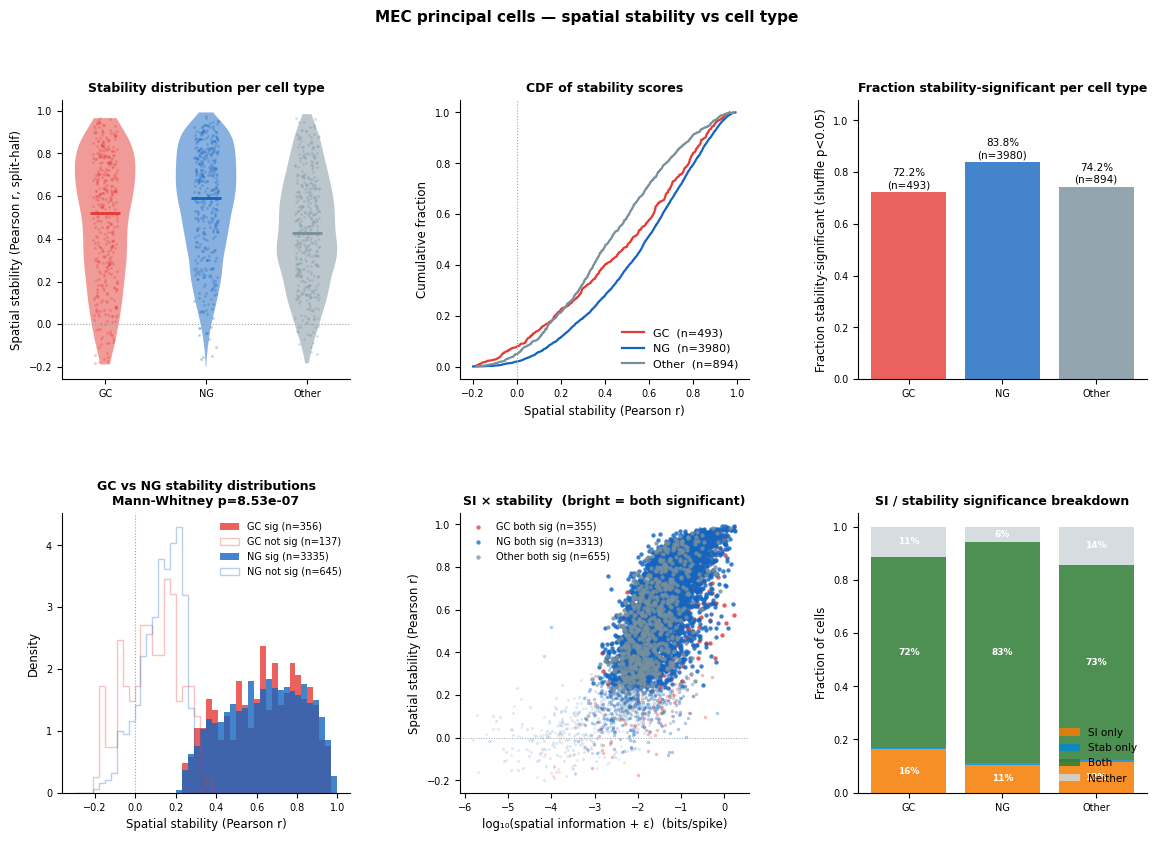

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9),
                         gridspec_kw=dict(hspace=0.48, wspace=0.38))

# ── A: violin — stability per cell type ──────────────────────────────────────
ax = axes[0, 0]
for xi, ct in enumerate(TYPE_ORDER):
    sub = df[df['cell_type'] == ct]['stability'].dropna()
    if len(sub) == 0: continue
    parts = ax.violinplot(sub, positions=[xi], widths=0.6,
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(TYPE_COLOURS[ct]); pc.set_alpha(0.5)
    parts['cmedians'].set_color(TYPE_COLOURS[ct])
    parts['cmedians'].set_linewidth(2.0)
    rng    = np.random.default_rng(xi)
    n_show = min(len(sub), 400)
    idx_s  = rng.choice(len(sub), n_show, replace=False)
    jitter = rng.uniform(-0.12, 0.12, n_show)
    ax.scatter(xi + jitter, sub.iloc[idx_s],
               s=4, color=TYPE_COLOURS[ct], alpha=0.30, lw=0)
ax.axhline(0, color='#90A4AE', lw=0.8, ls=':')
ax.set_xticks(range(len(TYPE_ORDER)))
ax.set_xticklabels(TYPE_ORDER, fontsize=9)
ax.set_ylabel('Spatial stability (Pearson r, split-half)', fontsize=8.5)
ax.set_title('Stability distribution per cell type', fontsize=9, fontweight='bold')
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── B: CDF per cell type ──────────────────────────────────────────────────────
ax = axes[0, 1]
for ct in TYPE_ORDER:
    sub = np.sort(df[df['cell_type'] == ct]['stability'].dropna().values)
    cdf = np.arange(1, len(sub)+1) / len(sub)
    ax.plot(sub, cdf, color=TYPE_COLOURS[ct], lw=1.6, label=f'{ct}  (n={len(sub)})')
ax.axvline(0, color='#90A4AE', lw=0.8, ls=':')
ax.set_xlabel('Spatial stability (Pearson r)', fontsize=8.5)
ax.set_ylabel('Cumulative fraction', fontsize=8.5)
ax.set_title('CDF of stability scores', fontsize=9, fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── C: fraction stability sig per cell type ───────────────────────────────────
ax = axes[0, 2]
frac_sig = [df[df['cell_type'] == ct]['st_sig'].mean() for ct in TYPE_ORDER]
n_cells  = [df[df['cell_type'] == ct]['st_sig'].count() for ct in TYPE_ORDER]
bars = ax.bar(range(len(TYPE_ORDER)), frac_sig,
              color=[TYPE_COLOURS[ct] for ct in TYPE_ORDER], alpha=0.80, lw=0)
ax.set_xticks(range(len(TYPE_ORDER)))
ax.set_xticklabels(TYPE_ORDER, fontsize=9)
ax.set_ylabel('Fraction stability-significant (shuffle p<0.05)', fontsize=8.5)
ax.set_title('Fraction stability-significant per cell type', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.08)
for bar, frac, n in zip(bars, frac_sig, n_cells):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{frac*100:.1f}%\n(n={n})', ha='center', va='bottom', fontsize=7.5)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── D: GC vs NG stability histograms split by sig ────────────────────────────
ax = axes[1, 0]
bins = np.linspace(-0.3, 1.0, 45)
for ct in ['GC', 'NG']:
    sub  = df[df['cell_type'] == ct]
    sig  = sub[sub['st_sig']]['stability'].dropna()
    nsig = sub[~sub['st_sig']]['stability'].dropna()
    ax.hist(sig,  bins=bins, color=TYPE_COLOURS[ct], alpha=0.80,
            density=True, histtype='stepfilled', lw=0, label=f'{ct} sig (n={len(sig)})')
    ax.hist(nsig, bins=bins, color=TYPE_COLOURS[ct], alpha=0.30,
            density=True, histtype='step', lw=1.5, ls='--',
            label=f'{ct} not sig (n={len(nsig)})')
_, mwu_p_st = mannwhitneyu(
    df[df['cell_type']=='GC']['stability'].dropna(),
    df[df['cell_type']=='NG']['stability'].dropna(),
    alternative='two-sided'
)
ax.axvline(0, color='#90A4AE', lw=0.8, ls=':')
ax.set_xlabel('Spatial stability (Pearson r)', fontsize=8.5)
ax.set_ylabel('Density', fontsize=8.5)
ax.set_title(f'GC vs NG stability distributions\nMann-Whitney p={mwu_p_st:.2e}',
             fontsize=9, fontweight='bold')
ax.legend(fontsize=7, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── E: Joint SI × stability scatter ──────────────────────────────────────────
ax = axes[1, 1]
for ct in TYPE_ORDER:
    sub    = df[df['cell_type'] == ct].dropna(subset=['spatial_information','stability'])
    both   = sub[sub['si_sig'] & sub['st_sig']]
    either = sub[sub['si_sig'] | sub['st_sig']]
    neither_m = sub[~(sub['si_sig'] | sub['st_sig'])]
    ax.scatter(np.log10(neither_m['spatial_information'] + 1e-6),
               neither_m['stability'],
               s=5, color=TYPE_COLOURS[ct], alpha=0.15, lw=0)
    ax.scatter(np.log10(either['spatial_information'] + 1e-6),
               either['stability'],
               s=6, color=TYPE_COLOURS[ct], alpha=0.35, lw=0)
    ax.scatter(np.log10(both['spatial_information'] + 1e-6),
               both['stability'],
               s=10, color=TYPE_COLOURS[ct], alpha=0.75, lw=0,
               label=f'{ct} both sig (n={len(both)})')

ax.axhline(0, color='#90A4AE', lw=0.7, ls=':')
ax.set_xlabel('log₁₀(spatial information + ε)  (bits/spike)', fontsize=8.5)
ax.set_ylabel('Spatial stability (Pearson r)', fontsize=8.5)
ax.set_title('SI × stability  (bright = both significant)', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# ── F: fraction both-sig per cell type ───────────────────────────────────────
ax = axes[1, 2]
for xi, ct in enumerate(TYPE_ORDER):
    sub  = df[df['cell_type'] == ct]
    cats = {
        'SI only':    (sub['si_sig'] & ~sub['st_sig']).sum(),
        'Stab only':  (~sub['si_sig'] & sub['st_sig']).sum(),
        'Both':       (sub['si_sig'] & sub['st_sig']).sum(),
        'Neither':    (~sub['si_sig'] & ~sub['st_sig']).sum(),
    }
    bottom = 0
    colours = {'SI only': '#F57C00', 'Stab only': '#0288D1',
               'Both': '#2E7D32', 'Neither': '#CFD8DC'}
    for lbl, cnt in cats.items():
        frac = cnt / len(sub)
        ax.bar(xi, frac, bottom=bottom, color=colours[lbl], alpha=0.85, lw=0,
               label=lbl if xi == 0 else '_nolegend_')
        if frac > 0.04:
            ax.text(xi, bottom + frac/2, f'{frac*100:.0f}%',
                    ha='center', va='center', fontsize=6.5, color='white', fontweight='bold')
        bottom += frac
ax.set_xticks(range(len(TYPE_ORDER)))
ax.set_xticklabels(TYPE_ORDER, fontsize=9)
ax.set_ylabel('Fraction of cells', fontsize=8.5)
ax.set_title('SI / stability significance breakdown', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=7.5, frameon=False, loc='lower right')
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

fig.suptitle('MEC principal cells — spatial stability vs cell type',
             fontsize=11, fontweight='bold')
plt.savefig('vr_stability_cell_types.pdf', bbox_inches='tight', dpi=150)
plt.show()

---
## Threshold exploration

Sweep absolute SI and stability thresholds to decide which NG cells to classify as spatial.

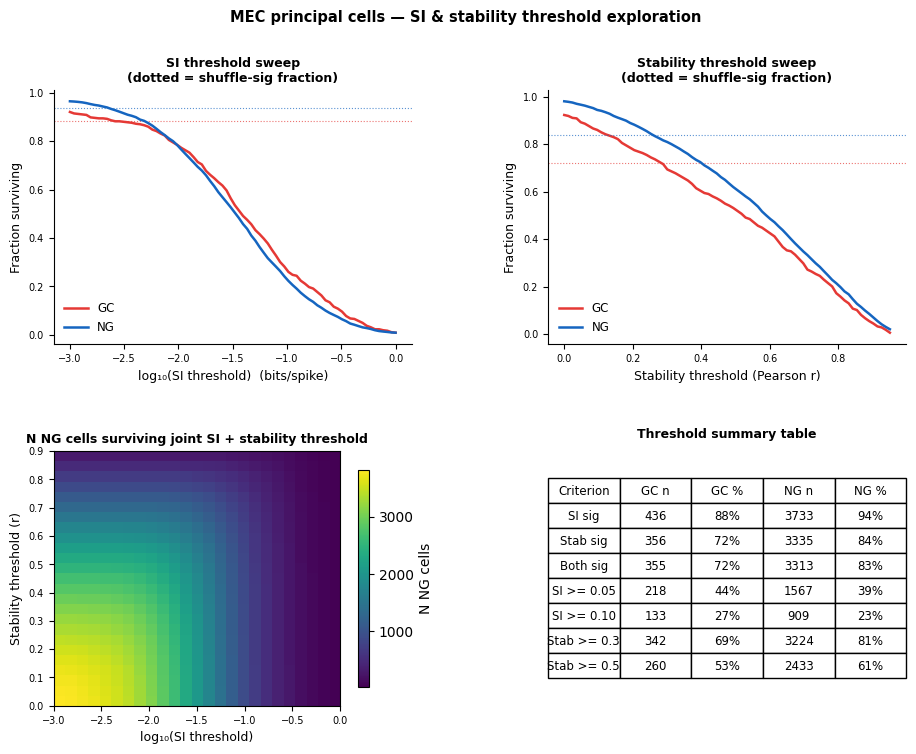

In [7]:
si_thresholds = np.logspace(-3, 0, 80)    # 0.001 – 1.0 bits/spike
st_thresholds = np.linspace(0.0, 0.95, 80)

fig, axes = plt.subplots(2, 2, figsize=(11, 8),
                         gridspec_kw=dict(hspace=0.42, wspace=0.38))

# A: Fraction surviving SI threshold
ax = axes[0, 0]
for ct in ['GC', 'NG']:
    si   = df[df['cell_type'] == ct]['spatial_information'].dropna().values
    frac = [(si >= t).mean() for t in si_thresholds]
    ax.plot(np.log10(si_thresholds), frac, color=TYPE_COLOURS[ct], lw=1.8, label=ct)
    ax.axhline(df[df['cell_type']==ct]['si_sig'].mean(),
               color=TYPE_COLOURS[ct], lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel('log₁₀(SI threshold)  (bits/spike)', fontsize=9)
ax.set_ylabel('Fraction surviving', fontsize=9)
ax.set_title('SI threshold sweep\n(dotted = shuffle-sig fraction)', fontsize=9, fontweight='bold')
ax.legend(fontsize=8.5, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# B: Fraction surviving stability threshold
ax = axes[0, 1]
for ct in ['GC', 'NG']:
    st   = df[df['cell_type'] == ct]['stability'].dropna().values
    frac = [(st >= t).mean() for t in st_thresholds]
    ax.plot(st_thresholds, frac, color=TYPE_COLOURS[ct], lw=1.8, label=ct)
    ax.axhline(df[df['cell_type']==ct]['st_sig'].mean(),
               color=TYPE_COLOURS[ct], lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel('Stability threshold (Pearson r)', fontsize=9)
ax.set_ylabel('Fraction surviving', fontsize=9)
ax.set_title('Stability threshold sweep\n(dotted = shuffle-sig fraction)', fontsize=9, fontweight='bold')
ax.legend(fontsize=8.5, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

# C: N NG cells surviving joint SI + stability threshold (heatmap)
ax = axes[1, 0]
ng = df[df['cell_type'] == 'NG'].dropna(subset=['spatial_information','stability'])
si_grid = np.logspace(-3, 0, 25)
st_grid = np.linspace(0, 0.9, 25)
mat = np.zeros((len(st_grid), len(si_grid)))
for i, st_t in enumerate(st_grid):
    for j, si_t in enumerate(si_grid):
        mat[i, j] = ((ng['spatial_information'] >= si_t) &
                     (ng['stability'] >= st_t)).sum()
im = ax.imshow(mat, origin='lower', aspect='auto',
               extent=[np.log10(si_grid[0]), np.log10(si_grid[-1]),
                       st_grid[0], st_grid[-1]],
               cmap='viridis')
plt.colorbar(im, ax=ax, label='N NG cells', shrink=0.85)
ax.set_xlabel('log₁₀(SI threshold)', fontsize=9)
ax.set_ylabel('Stability threshold (r)', fontsize=9)
ax.set_title('N NG cells surviving joint SI + stability threshold', fontsize=9, fontweight='bold')
ax.tick_params(labelsize=7)

# D: Summary table printed, scatter of sig status
ax = axes[1, 1]
ax.axis('off')
rows_tab = [['Criterion', 'GC n', 'GC %', 'NG n', 'NG %']]
for label, mask_gc, mask_ng in [
    ('SI sig',        df[df['cell_type']=='GC']['si_sig'],
                      df[df['cell_type']=='NG']['si_sig']),
    ('Stab sig',      df[df['cell_type']=='GC']['st_sig'],
                      df[df['cell_type']=='NG']['st_sig']),
    ('Both sig',      (df[df['cell_type']=='GC']['si_sig'] & df[df['cell_type']=='GC']['st_sig']),
                      (df[df['cell_type']=='NG']['si_sig'] & df[df['cell_type']=='NG']['st_sig'])),
    ('SI >= 0.05',    df[df['cell_type']=='GC']['spatial_information'] >= 0.05,
                      df[df['cell_type']=='NG']['spatial_information'] >= 0.05),
    ('SI >= 0.10',    df[df['cell_type']=='GC']['spatial_information'] >= 0.10,
                      df[df['cell_type']=='NG']['spatial_information'] >= 0.10),
    ('Stab >= 0.3',   df[df['cell_type']=='GC']['stability'] >= 0.3,
                      df[df['cell_type']=='NG']['stability'] >= 0.3),
    ('Stab >= 0.5',   df[df['cell_type']=='GC']['stability'] >= 0.5,
                      df[df['cell_type']=='NG']['stability'] >= 0.5),
]:
    n_gc = int(mask_gc.sum()); tot_gc = int(len(mask_gc))
    n_ng = int(mask_ng.sum()); tot_ng = int(len(mask_ng))
    rows_tab.append([label,
                     str(n_gc), f'{100*n_gc/tot_gc:.0f}%',
                     str(n_ng), f'{100*n_ng/tot_ng:.0f}%'])

table = ax.table(cellText=rows_tab[1:], colLabels=rows_tab[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.5)
ax.set_title('Threshold summary table', fontsize=9, fontweight='bold', pad=10)

fig.suptitle('MEC principal cells — SI & stability threshold exploration',
             fontsize=10.5, fontweight='bold')
plt.savefig('vr_threshold_exploration.pdf', bbox_inches='tight', dpi=150)
plt.show()

---
## Medial–lateral breakdown

Does the fraction of SI-significant or stability-significant cells vary along the MEC medial–lateral axis?
Cells are binned by `abs(SC_x)` (µm); each bin shows the fraction passing each criterion, separately for GC and NG.

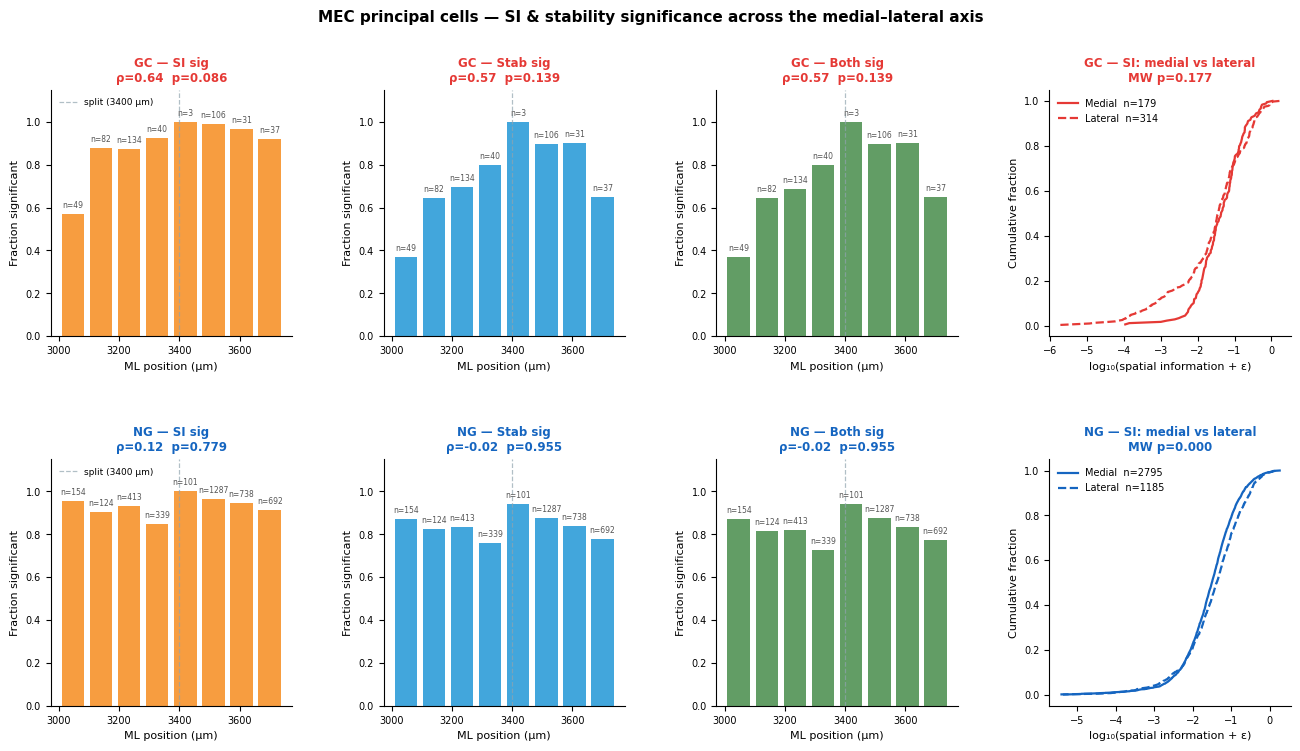


               Med SI%   Lat SI%   Med Stab%   Lat Stab%   Med Both%   Lat Both%
GC            96.6% (n=179)  83.8% (n=314)  84.4% (n=179)  65.3% (n=314)  84.4% (n=179)  65.0% (n=314)
NG            94.7% (n=2795)  91.7% (n=1185)  84.1% (n=2795)  83.1% (n=1185)  83.9% (n=2795)  81.6% (n=1185)


In [8]:
from scipy.stats import spearmanr, mannwhitneyu as _mwu

ML_SPLIT  = 3400   # µm — medial boundary
N_ML_BINS = 8

ml_min = df['ml'].quantile(0.02)
ml_max = df['ml'].quantile(0.98)
ml_edges  = np.linspace(ml_min, ml_max, N_ML_BINS + 1)
ml_centres = 0.5 * (ml_edges[:-1] + ml_edges[1:])

CRITERIA = [
    ('si_sig',              'SI sig',   '#F57C00'),
    ('st_sig',              'Stab sig', '#0288D1'),
    ('both_sig',            'Both sig', '#2E7D32'),
]
df['both_sig'] = df['si_sig'] & df['st_sig']

CT_GROUPS = [('GC', TYPE_COLOURS['GC']), ('NG', TYPE_COLOURS['NG'])]

fig, axes = plt.subplots(2, 4, figsize=(16, 8),
                         gridspec_kw=dict(hspace=0.50, wspace=0.38))

for row, (ct, ct_col) in enumerate(CT_GROUPS):
    sub_ct = df[df['cell_type'] == ct].copy()

    # ── Left 3 panels: fraction sig per ML bin for each criterion ────────────
    for col, (crit, crit_label, crit_col) in enumerate(CRITERIA):
        ax = axes[row, col]
        fracs, ns = [], []
        for lo, hi in zip(ml_edges[:-1], ml_edges[1:]):
            mask = (sub_ct['ml'] >= lo) & (sub_ct['ml'] < hi)
            grp  = sub_ct.loc[mask, crit].dropna()
            fracs.append(grp.mean() if len(grp) > 0 else np.nan)
            ns.append(len(grp))

        fracs = np.array(fracs)
        ax.bar(ml_centres, fracs, width=(ml_edges[1] - ml_edges[0]) * 0.80,
               color=crit_col, alpha=0.75, lw=0)
        # cell count above each bar
        for xc, frac, n in zip(ml_centres, fracs, ns):
            if np.isfinite(frac):
                ax.text(xc, frac + 0.02, f'n={n}', ha='center', va='bottom',
                        fontsize=5.5, color='#555')

        # Spearman correlation (exclude NaN bins)
        valid = np.isfinite(fracs)
        if valid.sum() >= 3:
            rho, pval = spearmanr(ml_centres[valid], fracs[valid])
            ax.set_title(f'{ct} — {crit_label}\nρ={rho:.2f}  p={pval:.3f}',
                         fontsize=8.5, fontweight='bold', color=ct_col)
        else:
            ax.set_title(f'{ct} — {crit_label}', fontsize=8.5,
                         fontweight='bold', color=ct_col)

        ax.set_xlabel('ML position (µm)', fontsize=8)
        ax.set_ylabel('Fraction significant', fontsize=8)
        ax.set_ylim(0, 1.15)
        ax.axvline(ML_SPLIT, color='#90A4AE', lw=0.9, ls='--', alpha=0.7,
                   label=f'split ({ML_SPLIT} µm)')
        if col == 0:
            ax.legend(fontsize=6.5, frameon=False)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(labelsize=7)

    # ── Right panel: medial vs lateral — SI score & stability distribution ───
    ax = axes[row, 3]
    med = sub_ct[sub_ct['ml'] >= ML_SPLIT]
    lat = sub_ct[sub_ct['ml'] <  ML_SPLIT]

    for grp, lbl, ls in [(med, 'Medial', '-'), (lat, 'Lateral', '--')]:
        si_vals = np.sort(grp['spatial_information'].dropna().values)
        if len(si_vals) == 0: continue
        cdf = np.arange(1, len(si_vals)+1) / len(si_vals)
        ax.plot(np.log10(si_vals + 1e-6), cdf, color=ct_col, lw=1.6, ls=ls,
                label=f'{lbl}  n={len(si_vals)}')

    _, p_si = _mwu(med['spatial_information'].dropna(),
                   lat['spatial_information'].dropna(),
                   alternative='two-sided')
    ax.set_xlabel('log₁₀(spatial information + ε)', fontsize=8)
    ax.set_ylabel('Cumulative fraction', fontsize=8)
    ax.set_title(f'{ct} — SI: medial vs lateral\nMW p={p_si:.3f}',
                 fontsize=8.5, fontweight='bold', color=ct_col)
    ax.legend(fontsize=7, frameon=False)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=7)

fig.suptitle('MEC principal cells — SI & stability significance across the medial–lateral axis',
             fontsize=11, fontweight='bold')
plt.savefig('vr_spatial_info_ml_breakdown.pdf', bbox_inches='tight', dpi=150)
plt.show()

# ── Summary: medial vs lateral significance fractions ─────────────────────────
print(f'\n{"":12s}  {"Med SI%":>8s}  {"Lat SI%":>8s}  {"Med Stab%":>10s}  {"Lat Stab%":>10s}  {"Med Both%":>10s}  {"Lat Both%":>10s}')
for ct, _ in CT_GROUPS:
    sub_ct = df[df['cell_type'] == ct]
    med = sub_ct[sub_ct['ml'] >= ML_SPLIT]
    lat = sub_ct[sub_ct['ml'] <  ML_SPLIT]
    row_vals = [ct]
    for crit in ['si_sig', 'st_sig', 'both_sig']:
        row_vals += [f'{100*med[crit].mean():.1f}% (n={len(med)})',
                     f'{100*lat[crit].mean():.1f}% (n={len(lat)})']
    print(f'{row_vals[0]:12s}  {row_vals[1]:>8s}  {row_vals[2]:>8s}  '
          f'{row_vals[3]:>10s}  {row_vals[4]:>10s}  {row_vals[5]:>10s}  {row_vals[6]:>10s}')

---
## Medial–lateral breakdown by cortical depth

Repeat the ML gradient analysis separately for **superficial (layers 1–3)** and **deep (layers 5–6)**
ENTm cells. Deep cells are enriched laterally, so confounding depth effects with ML position
is a real risk — this separates the two.

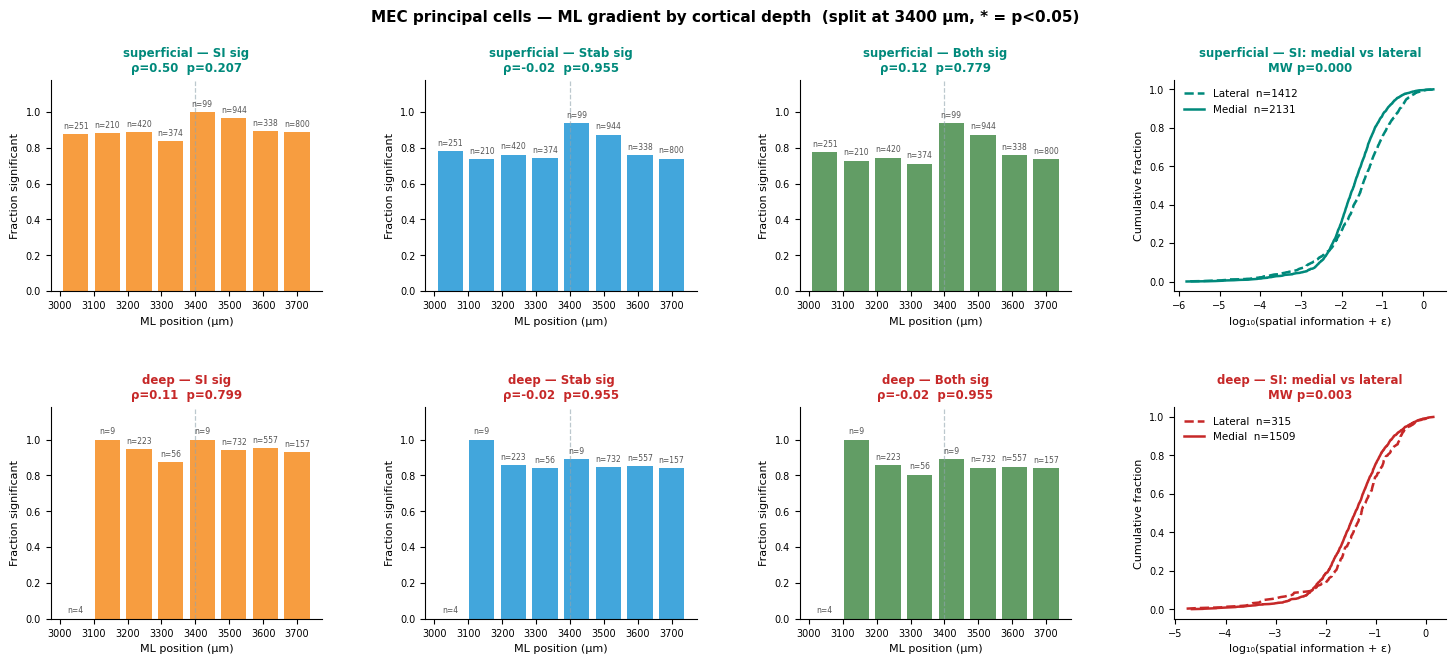


Depth           Med SI%    Lat SI%   Med Stab%   Lat Stab%   Med Both%   Lat Both%
superficial   92.4% (n=2131)  88.3% (n=1412)  80.4% (n=2131)  77.5% (n=1412)  80.2% (n=2131)  76.0% (n=1412)
deep          94.2% (n=1509)  92.1% (n=315)  84.8% (n=1509)  84.8% (n=315)  84.6% (n=1509)  84.1% (n=315)


In [9]:
from scipy.stats import spearmanr as _spr, mannwhitneyu as _mwu2

N_ML_BINS_D = 8
ml_min_d = df['ml'].quantile(0.02)
ml_max_d = df['ml'].quantile(0.98)
ml_edges_d   = np.linspace(ml_min_d, ml_max_d, N_ML_BINS_D + 1)
ml_centres_d = 0.5 * (ml_edges_d[:-1] + ml_edges_d[1:])

DEPTHS    = ['superficial', 'deep']
CRITERIA_D = [
    ('si_sig',   'SI sig',   '#F57C00'),
    ('st_sig',   'Stab sig', '#0288D1'),
    ('both_sig', 'Both sig', '#2E7D32'),
]

fig, axes = plt.subplots(len(DEPTHS), 4, figsize=(18, 7),
                         gridspec_kw=dict(hspace=0.55, wspace=0.38))

for row, depth in enumerate(DEPTHS):
    sub_d   = df[df['depth'] == depth].copy()
    d_col   = DEPTH_COLOURS[depth]

    # ── Cols 0-2: fraction sig per ML bin ────────────────────────────────────
    for col, (crit, crit_label, crit_col) in enumerate(CRITERIA_D):
        ax = axes[row, col]
        fracs, ns = [], []
        for lo, hi in zip(ml_edges_d[:-1], ml_edges_d[1:]):
            mask = (sub_d['ml'] >= lo) & (sub_d['ml'] < hi)
            grp  = sub_d.loc[mask, crit].dropna()
            fracs.append(grp.mean() if len(grp) >= 3 else np.nan)
            ns.append(len(grp))

        fracs = np.array(fracs)
        ax.bar(ml_centres_d, np.where(np.isfinite(fracs), fracs, 0),
               width=(ml_edges_d[1] - ml_edges_d[0]) * 0.80,
               color=crit_col, alpha=0.75, lw=0)
        for xc, frac, n in zip(ml_centres_d, fracs, ns):
            if np.isfinite(frac):
                ax.text(xc, frac + 0.02, f'n={n}', ha='center', va='bottom',
                        fontsize=5.5, color='#555')

        valid = np.isfinite(fracs)
        if valid.sum() >= 3:
            rho, pval = _spr(ml_centres_d[valid], fracs[valid])
            sig_star  = '*' if pval < 0.05 else ''
            ax.set_title(f'{depth} — {crit_label}{sig_star}\nρ={rho:.2f}  p={pval:.3f}',
                         fontsize=8.5, fontweight='bold', color=d_col)
        else:
            ax.set_title(f'{depth} — {crit_label}', fontsize=8.5,
                         fontweight='bold', color=d_col)

        ax.set_xlabel('ML position (µm)', fontsize=8)
        ax.set_ylabel('Fraction significant', fontsize=8)
        ax.set_ylim(0, 1.18)
        ax.axvline(ML_SPLIT, color='#90A4AE', lw=0.9, ls='--', alpha=0.6)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(labelsize=7)

    # ── Col 3: medial vs lateral SI CDF ──────────────────────────────────────
    ax = axes[row, 3]
    med_d = sub_d[sub_d['ml'] >= ML_SPLIT]
    lat_d = sub_d[sub_d['ml'] <  ML_SPLIT]

    for grp, lbl, ls in [(lat_d, 'Lateral', '--'), (med_d, 'Medial', '-')]:
        si_v = np.sort(grp['spatial_information'].dropna().values)
        if len(si_v) == 0: continue
        cdf  = np.arange(1, len(si_v)+1) / len(si_v)
        ax.plot(np.log10(si_v + 1e-6), cdf, color=d_col, lw=1.8, ls=ls,
                label=f'{lbl}  n={len(si_v)}')

    if len(med_d['spatial_information'].dropna()) >= 3 and \
       len(lat_d['spatial_information'].dropna()) >= 3:
        _, p_si2 = _mwu2(med_d['spatial_information'].dropna(),
                          lat_d['spatial_information'].dropna(),
                          alternative='two-sided')
        p_str = f'MW p={p_si2:.3f}'
    else:
        p_str = 'insufficient n'

    ax.set_xlabel('log₁₀(spatial information + ε)', fontsize=8)
    ax.set_ylabel('Cumulative fraction', fontsize=8)
    ax.set_title(f'{depth} — SI: medial vs lateral\n{p_str}',
                 fontsize=8.5, fontweight='bold', color=d_col)
    ax.legend(fontsize=7.5, frameon=False)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=7)

fig.suptitle('MEC principal cells — ML gradient by cortical depth  '
             f'(split at {ML_SPLIT} µm, * = p<0.05)',
             fontsize=11, fontweight='bold')
plt.savefig('vr_spatial_info_ml_by_depth.pdf', bbox_inches='tight', dpi=150)
plt.show()

# ── Printed summary ───────────────────────────────────────────────────────────
print(f'\n{"Depth":12s}  {"Med SI%":>9s}  {"Lat SI%":>9s}  '
      f'{"Med Stab%":>10s}  {"Lat Stab%":>10s}  {"Med Both%":>10s}  {"Lat Both%":>10s}')
for depth in DEPTHS:
    sub_d = df[df['depth'] == depth]
    med_d = sub_d[sub_d['ml'] >= ML_SPLIT]
    lat_d = sub_d[sub_d['ml'] <  ML_SPLIT]
    vals  = [depth]
    for crit in ['si_sig', 'st_sig', 'both_sig']:
        vals += [f'{100*med_d[crit].mean():.1f}% (n={len(med_d)})',
                 f'{100*lat_d[crit].mean():.1f}% (n={len(lat_d)})']
    print(f'{vals[0]:12s}  {vals[1]:>9s}  {vals[2]:>9s}  '
          f'{vals[3]:>10s}  {vals[4]:>10s}  {vals[5]:>10s}  {vals[6]:>10s}')

---
## CDF across fixed ML bins (3000–3800 µm, 200 µm steps)

Four CDFs per panel using fixed absolute ML bins starting at 3000 µm, separately for
**superficial** and **deep** ENTm. Rows show spatial information (top) and spatial
stability (bottom).

Cells with ml in [3000, 3800) µm: 5295 / 5367
  superficial: [np.int64(630), np.int64(724), np.int64(944), np.int64(1187)] per bin
  deep: [np.int64(59), np.int64(242), np.int64(732), np.int64(777)] per bin


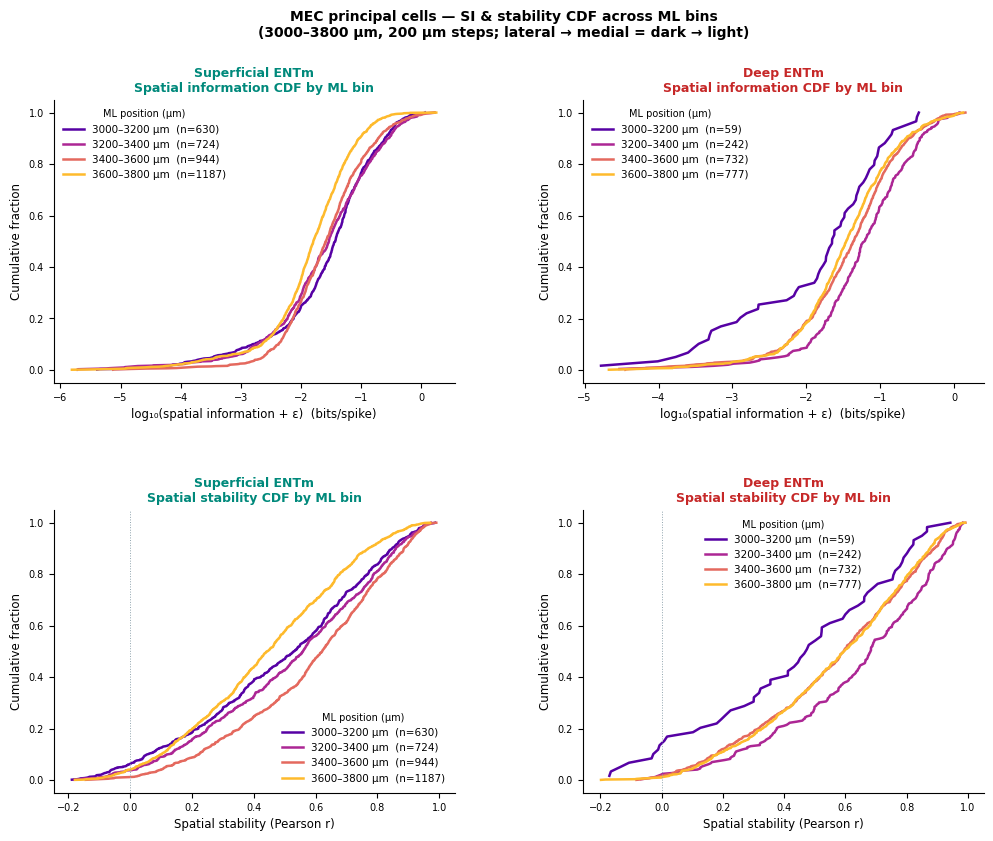

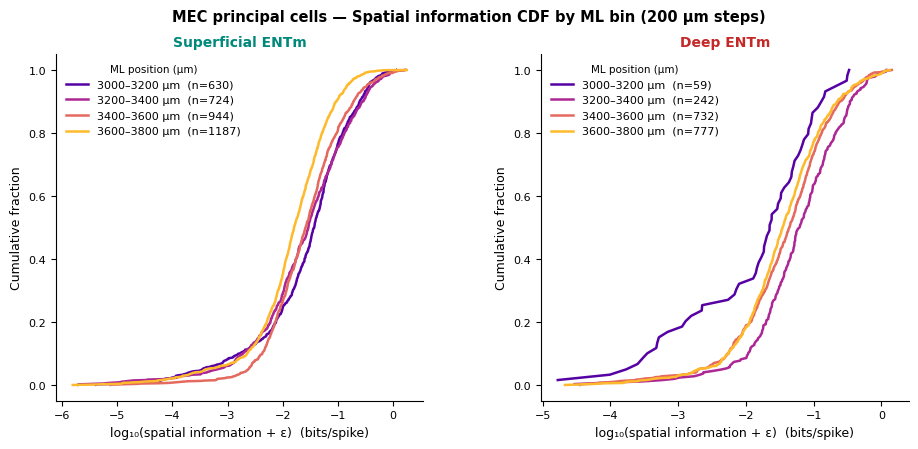

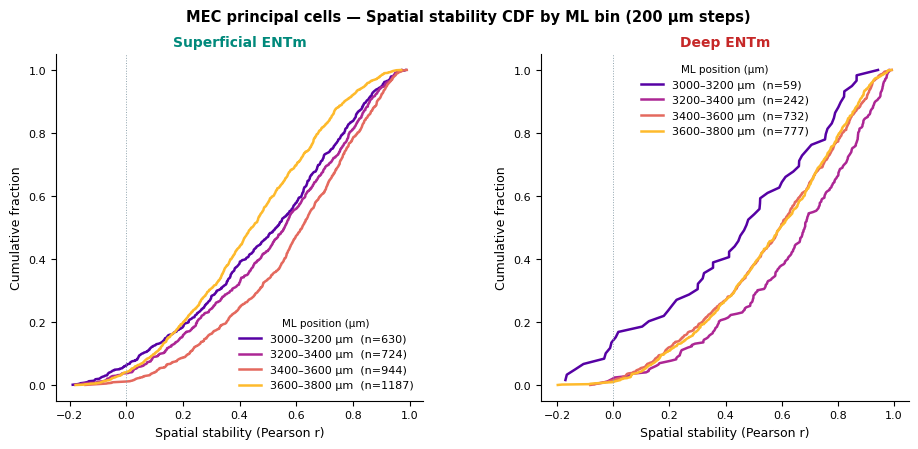

In [10]:
ML_BIN_EDGES  = [3000, 3200, 3400, 3600, 3800]   # 4 bins × 200 µm
N_ML_FIXED    = len(ML_BIN_EDGES) - 1
BIN_LABELS    = [f'{ML_BIN_EDGES[i]}–{ML_BIN_EDGES[i+1]}' for i in range(N_ML_FIXED)]
bin_colours   = [plt.cm.plasma(v) for v in np.linspace(0.15, 0.85, N_ML_FIXED)]

# Check coverage
in_range = (df['ml'] >= ML_BIN_EDGES[0]) & (df['ml'] < ML_BIN_EDGES[-1])
print(f'Cells with ml in [{ML_BIN_EDGES[0]}, {ML_BIN_EDGES[-1]}) µm: '
      f'{in_range.sum()} / {len(df)}')
for depth in ['superficial', 'deep']:
    sub = df[(df['depth'] == depth) & in_range]
    ns  = [(sub['ml'] >= ML_BIN_EDGES[i]) & (sub['ml'] < ML_BIN_EDGES[i+1])
           for i in range(N_ML_FIXED)]
    counts = [m.sum() for m in ns]
    print(f'  {depth}: {counts} per bin')

# ── 2×2 figure ────────────────────────────────────────────────────────────────
#   rows: SI (top) / stability (bottom)
#   cols: superficial (left) / deep (right)
fig, axes = plt.subplots(2, 2, figsize=(12, 9),
                         gridspec_kw=dict(hspace=0.45, wspace=0.32))

METRICS = [
    ('spatial_information', 'log₁₀(spatial information + ε)  (bits/spike)',
     True,  'vr_si_cdf_ml_bins.pdf'),
    ('stability',           'Spatial stability (Pearson r)',
     False, 'vr_stability_cdf_ml_bins.pdf'),
]

for row, (metric, xlabel, log_scale, _) in enumerate(METRICS):
    for col, depth in enumerate(['superficial', 'deep']):
        ax   = axes[row, col]
        sub_d = df[df['depth'] == depth]

        for bi in range(N_ML_FIXED):
            lo   = ML_BIN_EDGES[bi]
            hi   = ML_BIN_EDGES[bi + 1]
            mask = (sub_d['ml'] >= lo) & (sub_d['ml'] < hi)
            vals = sub_d.loc[mask, metric].dropna().values
            if len(vals) < 3:
                continue
            vals_sorted = np.sort(vals)
            cdf  = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)
            x    = np.log10(vals_sorted + 1e-6) if log_scale else vals_sorted
            ax.plot(x, cdf, color=bin_colours[bi], lw=1.8,
                    label=f'{BIN_LABELS[bi]} µm  (n={len(vals)})')

        if not log_scale:
            ax.axvline(0, color='#90A4AE', lw=0.7, ls=':')

        ax.set_xlabel(xlabel, fontsize=8.5)
        ax.set_ylabel('Cumulative fraction', fontsize=8.5)
        ax.set_title(f'{depth.capitalize()} ENTm\n'
                     f'{"Spatial information" if row==0 else "Spatial stability"} CDF by ML bin',
                     fontsize=9, fontweight='bold', color=DEPTH_COLOURS[depth])
        ax.legend(fontsize=7.5, frameon=False, title='ML position (µm)', title_fontsize=7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7)

fig.suptitle('MEC principal cells — SI & stability CDF across ML bins\n'
             '(3000–3800 µm, 200 µm steps; lateral → medial = dark → light)',
             fontsize=10, fontweight='bold')
plt.savefig('vr_cdf_ml_bins_by_depth.pdf', bbox_inches='tight', dpi=150)
plt.show()

# ── Save SI and stability separately too ──────────────────────────────────────
for row, (metric, xlabel, log_scale, out_pdf) in enumerate(METRICS):
    fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.5),
                               gridspec_kw=dict(wspace=0.32))
    for col, depth in enumerate(['superficial', 'deep']):
        ax    = axes2[col]
        sub_d = df[df['depth'] == depth]
        for bi in range(N_ML_FIXED):
            lo   = ML_BIN_EDGES[bi]
            hi   = ML_BIN_EDGES[bi + 1]
            mask = (sub_d['ml'] >= lo) & (sub_d['ml'] < hi)
            vals = sub_d.loc[mask, metric].dropna().values
            if len(vals) < 3:
                continue
            vals_sorted = np.sort(vals)
            cdf  = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)
            x    = np.log10(vals_sorted + 1e-6) if log_scale else vals_sorted
            ax.plot(x, cdf, color=bin_colours[bi], lw=1.8,
                    label=f'{BIN_LABELS[bi]} µm  (n={len(vals)})')
        if not log_scale:
            ax.axvline(0, color='#90A4AE', lw=0.7, ls=':')
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Cumulative fraction', fontsize=9)
        ax.set_title(f'{depth.capitalize()} ENTm', fontsize=10, fontweight='bold',
                     color=DEPTH_COLOURS[depth])
        ax.legend(fontsize=8, frameon=False, title='ML position (µm)', title_fontsize=7.5)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)
    metric_name = 'Spatial information' if log_scale else 'Spatial stability'
    fig2.suptitle(f'MEC principal cells — {metric_name} CDF by ML bin (200 µm steps)',
                  fontsize=10.5, fontweight='bold')
    plt.savefig(out_pdf, bbox_inches='tight', dpi=150)
    plt.show()